# 04 · Modelo: Random Forest

**Proyecto Final — Machine Learning y Deep Learning**

Este notebook se centra en **un solo modelo**: **muchos árboles que votan**; robusto y potente. Sigue la misma estructura que el resto de notebooks de modelo, para poder compararlos con facilidad.

> 📖 Términos técnicos explicados en `docs/glosario.md`. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb); la comparación de todos los modelos, en [`07_comparativa_modelos.ipynb`](07_comparativa_modelos.ipynb).

## 1. Cómo funciona

Un **Random Forest** (bosque aleatorio) es un **conjunto** (*ensemble*) de muchos árboles de decisión. Cada árbol se entrena con una **muestra aleatoria** de filas (*bagging*) y, en cada división, solo considera un **subconjunto aleatorio** de variables. La predicción final es el **voto/promedio** de todos los árboles.

Esa doble aleatoriedad hace que los árboles sean **diferentes entre sí**; al promediarlos se **reduce el sobreajuste** de un árbol individual. Suele dar muy buen rendimiento sin apenas ajuste y aporta una **importancia de variables** útil para interpretar.

## 2. Los datos

Usamos el **mismo preprocesado compartido** por todos los modelos (`src/preprocessing.py`): imputación de huecos, estandarización de las numéricas y *one-hot* de las categóricas. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb). Cargamos y dividimos en train/test (estratificado, semilla fija) con `load_and_prepare()`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
from src import config
from src.data_loader import load_and_prepare
from src.preprocessing import build_preprocessor

X_train, X_test, y_train, y_test = load_and_prepare()
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

def evaluar(pipe, etiqueta):
    """Imprime las métricas de test del pipeline y devuelve su ROC-AUC."""
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    m = dict(accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred),
             recall=recall_score(y_test, pred), f1=f1_score(y_test, pred),
             roc_auc=roc_auc_score(y_test, proba))
    print(f"{etiqueta:12s} | " + ' | '.join(f'{k}={v:.4f}' for k, v in m.items()))
    return m['roc_auc']

Entrenamiento: (95368, 28) | Prueba: (23842, 28)


## 3. Los hiperparámetros: ¿qué controla cada uno?

Los **hiperparámetros** son los ajustes que fijamos *antes* de entrenar (no se aprenden de los datos). Estos son los principales de este modelo:

| Hiperparámetro | Qué controla |
|---|---|
| `n_estimators` | Nº de árboles. Más árboles → predicción más estable (hasta saturar) y más lento. |
| `max_depth` | Profundidad de cada árbol (complejidad individual). |
| `min_samples_leaf` | Muestras mínimas por hoja (suaviza/regulariza). |
| `max_features` | Nº de variables candidatas por división (`sqrt`/`log2`). Controla la **diversidad** entre árboles. |
| `class_weight` | Reponderación de clases (`'balanced'`). |

## 4. Entrenamiento y evaluación (parámetros base)

Entrenamos el modelo con los hiperparámetros base y lo evaluamos sobre el conjunto de prueba (datos que no vio al entrenar).

In [2]:
# Pipeline = preprocesado + modelo (con los hiperparámetros base del proyecto)
from sklearn.ensemble import RandomForestClassifier
modelo = Pipeline([('preprocessor', build_preprocessor()), ('model', RandomForestClassifier(**config.RANDOM_FOREST_PARAMS))])
modelo.fit(X_train, y_train)
auc_base = evaluar(modelo, 'Base')

Base         | accuracy=0.8611 | precision=0.8871 | recall=0.7165 | f1=0.7927 | roc_auc=0.9431


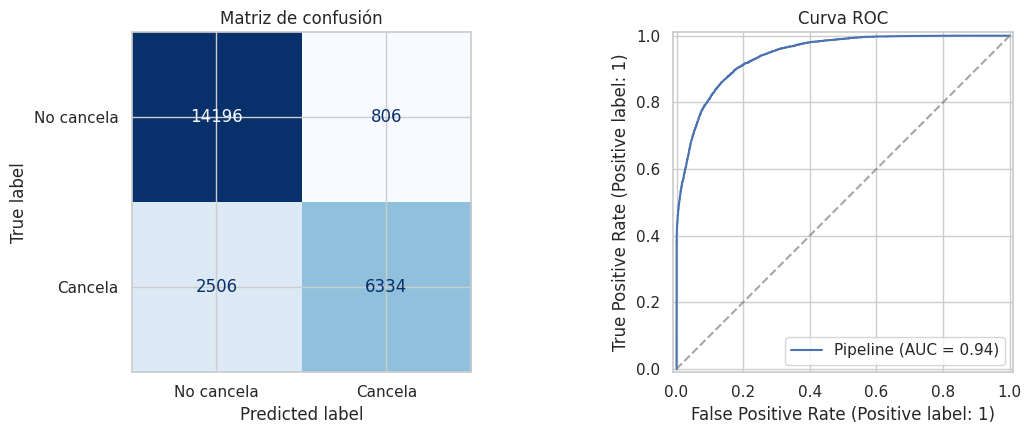

In [3]:
# Matriz de confusión y curva ROC de este modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=ax1,
    display_labels=['No cancela', 'Cancela'], cmap='Blues', colorbar=False)
ax1.set_title('Matriz de confusión')
RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7)
ax2.set_title('Curva ROC')
plt.tight_layout(); plt.show()

## 5. Optimización de hiperparámetros

Buscamos la mejor combinación con **RandomizedSearchCV (muestreo aleatorio de combinaciones)**, optimizando **ROC-AUC** por validación cruzada. (Es el mismo procedimiento, por modelo, que automatiza `src/tuning.py` para todo el proyecto.)

In [4]:
from sklearn.model_selection import RandomizedSearchCV

base_pipe = Pipeline([('preprocessor', build_preprocessor()), ('model', RandomForestClassifier(random_state=config.RANDOM_STATE, n_jobs=-1))])
busqueda = RandomizedSearchCV(base_pipe, config.RANDOM_FOREST_GRID, n_iter=config.TUNING_N_ITER, scoring='roc_auc', cv=config.TUNING_CV_FOLDS, n_jobs=-1, random_state=config.RANDOM_STATE)
busqueda.fit(X_train, y_train)
print('Mejores hiperparámetros:', busqueda.best_params_)
print(f'ROC-AUC (validación cruzada, {config.TUNING_CV_FOLDS} folds): {busqueda.best_score_:.4f}')

Mejores hiperparámetros: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 18}
ROC-AUC (validación cruzada, 3 folds): 0.9469


## 6. Resultado final y cuándo usar este modelo

Comparamos el rendimiento en test **antes y después** de optimizar:

In [5]:
auc_tuned = evaluar(busqueda.best_estimator_, 'Optimizado')
print(f'\nROC-AUC en test:  base {auc_base:.4f}  ->  optimizado {auc_tuned:.4f}')

Optimizado   | accuracy=0.8680 | precision=0.8852 | recall=0.7399 | f1=0.8061 | roc_auc=0.9482

ROC-AUC en test:  base 0.9431  ->  optimizado 0.9482


**Cuándo conviene:** como modelo **potente y robusto "de fábrica"**, poco sensible a la escala y con buena importancia de variables. Excelente opción por defecto cuando no quieres ajustar mucho.